494.73900056532176


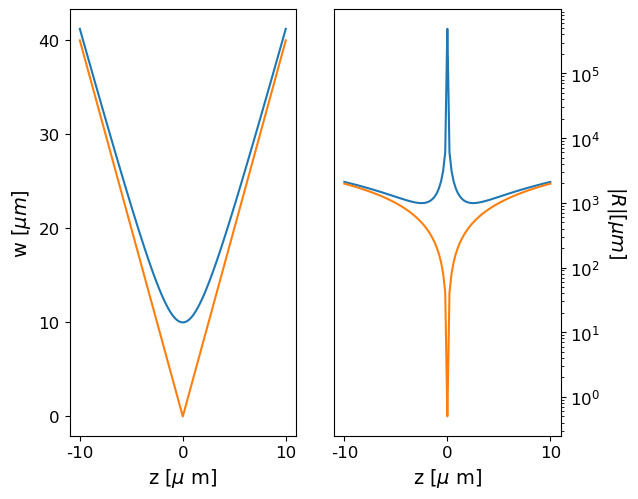

In [30]:
'''
G. Chirico
MArch 2026

computation of the features of the Gaussian beam

'''
import numpy as np
import matplotlib.pyplot as plt

def Gaussbeam(xx,yy,z,k0,w0,foc):
    """ parameters
    wav  = wavelength in um
    w0= beam spot in um
    k0 = 2pi / lambda
    zR = Rayleigh range
    """
    zR = w0*w0*k0/2.
    zf = z-foc
    rr = xx**2 +yy**2
    Gbeam = zR/(zR-1j*zf) * np.exp(-k0*rr/(2*(zR-1j*zf)))
    """
    print ('comp w0 =',2*foc/(k0*w0)/np.sqrt(1 + (foc/zR)**2),' um')
    print ('Rayleigh range=',zR, 'EP diameter=', w0*np.sqrt(1 + (foc/zR)**2))
    print (zf)
    """
    return Gbeam
###################################################
def getFWHM(xv,matrice):
  mask = matrice >= 0.5
  crossings = np.where(np.diff(mask))[0]
  return xv[crossings[1]] - xv[crossings[0]]
########################################################


wav = 0.635 

w0 = 10

zR = np.pi * w0**2/wav
print (zR)

zmin = -4* zR 
zmax = 4*zR

z = np.concatenate([
    np.linspace(zmin, -0.5, 50),
    np.linspace(0.5, zmax, 50)
])


w = w0*np.sqrt(1+(z/zR)**2)

wlin = np.abs(w0* z /zR)

R  = np.abs(z + zR**2/z)

Rlin = np.abs(z)

F,A = plt.subplots(1,2)

A[0].plot(z,w)
A[0].plot(z,wlin)
A[0].set_ylabel('w $[\mu m]$',fontsize= 14)

A[1].semilogy(z,R)
A[1].semilogy(z,Rlin)
A[1].set_ylabel('$ |R| [\mu m]$',fontsize= 14,rotation=270,
               labelpad=20, va='center')
A[1].yaxis.tick_right()
A[1].yaxis.set_label_position("right")

plt.tight_layout()

for a in A: 
    a.set_xlabel('z [$\mu$ m]',fontsize=14)
    a.set_xticks([zmin,0,zmax]) 
    a.set_xticklabels(['-10','0','10'])
    a.tick_params(axis='both', labelsize=12)


focal length =  9000  [um]
z= 8910.0  [um]; w0= 2 [um] ; zR= 19.79 [um]


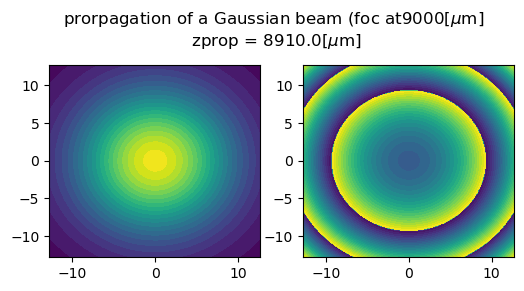

In [39]:

wav   = 0.635
kappa = 1/wav
k0 = 2*np.pi/wav
w0 = 2 # um
Npix=256
upix= 0.1 ## um

zR   = np.pi*w0**2/wav  ### in
foc  = 9000 # um
print ('focal length = ',foc,' [um]')
z    = foc*0.99  ##
print ('z=',z,' [um]; w0=',w0,'[um] ; zR=',np.round(zR,2), '[um]')


x     = np.linspace(-Npix//2,Npix//2-1,Npix) * upix
xx0,yy0 = np.meshgrid(x,x)

Gbeam = Gaussbeam(xx0,yy0,z,k0,w0,foc)
F,ax = plt.subplots(1,2,figsize=(6,2.5))
F.suptitle('prorpagation of a Gaussian beam (foc at'+str(foc)+'[$\mu$m] \n zprop = '+str(z)+'[$\mu$m]',y=1.1)
ax[0].contourf(xx0,yy0,np.abs(Gbeam),levels=25)
ax[1].contourf(xx0,yy0,np.angle(Gbeam),levels=25)
